# DomesticDeclarations Dataset Overview

This notebook provides a comprehensive overview of the DomesticDeclarations dataset:

1. **Basic Statistics**: Number of cases, events, and case lengths
2. **Activity Distribution**: Frequency of each activity type
3. **Process Variants**: Most common activity sequences
4. **Temporal Patterns**: Case duration statistics

## 1. Setup

In [17]:
# Path setup and config import
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

PROJECT_ROOT = _current

# Add both project root and src/ to path
if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

from src.interpretability.config.domestic_declarations_config import CONFIG
print(f"Dataset: {CONFIG.dataset_name}")

Dataset: DomesticDeclarations


In [18]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from IPython.display import display, HTML

from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [19]:
# Load model and test data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    all_cat=CONFIG.all_cat,
    all_num=CONFIG.all_num
)

print(f"Model loaded from: {CONFIG.get_model_path()}")
print(f"Test data loaded from: {CONFIG.get_test_data_path()}")

Data set categories:  ([('Activity', 10, {'APPROVED': 1, 'EOS': 2, 'FINAL_APPROVED': 3, 'FOR_APPROVAL': 4, 'Payment Handled': 5, 'REJECTED': 6, 'Request Payment': 7, 'SAVED': 8, 'SUBMITTED': 9}), ('Resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('Role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {}), ('Amount', 1, {})])
Encoder input features:  [['Activity', 'Resource', 'Role'], ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day', 'Amount']]
Decoder input+output features:  [['Activity', 'Resource'], ['case_elapsed_time', 'event_elapsed_time']]


Sequence length of decoder output:  4


Cells hidden size:  64
Number of LSTM layer:  2
Dropout rate:  0.0


Encoder number of labels for each input feature (categorical, numerical):  [[10, 4, 9], [1, 1, 1, 1,

## 2. Basic Dataset Statistics

In [20]:
# Helper function to get category mapping
def get_category_mapping(model, feature_name):
    """Get the value mapping dict for a categorical feature."""
    cat_features = model.data_set_categories[0]
    for feat_name, num_values, mapping in cat_features:
        if feat_name == feature_name:
            return mapping
    return {}

# Get activity mapping
activity_mapping = get_category_mapping(model, CONFIG.concept_name)
idx_to_activity = {v: k for k, v in activity_mapping.items()}

print(f"Activity mapping has {len(activity_mapping)} activities")

Activity mapping has 9 activities


In [21]:
# Extract case statistics
case_lengths = []
all_activities = []
case_activity_sequences = {}  # case_name -> list of activities

for case_name, case_data in eval_helper.cases.items():
    cat_data = case_data[0]  # Categorical features
    activity_idx = CONFIG.all_cat.index(CONFIG.concept_name)
    activity_tensor = cat_data[activity_idx]
    
    # Extract activities (excluding padding/special tokens)
    activities = []
    for i in range(len(activity_tensor)):
        act_idx = activity_tensor[i].item()
        act_name = idx_to_activity.get(act_idx, f'Unknown_{act_idx}')
        if act_name not in ['PAD', 'EOS', 'SOS', '<PAD>', '<EOS>', '<SOS>']:
            activities.append(act_name)
            all_activities.append(act_name)
    
    case_lengths.append(len(activities))
    case_activity_sequences[case_name] = activities

# Compute statistics
num_cases = len(eval_helper.cases)
total_events = sum(case_lengths)
avg_length = np.mean(case_lengths)
median_length = np.median(case_lengths)
min_length = min(case_lengths)
max_length = max(case_lengths)
std_length = np.std(case_lengths)

print("="*70)
print(f"DOMESTIC DECLARATIONS - DATASET OVERVIEW (Test Set)")
print("="*70)
print(f"\n{'Metric':<30} {'Value':>15}")
print("-"*45)
print(f"{'Number of Cases':<30} {num_cases:>15,}")
print(f"{'Total Events':<30} {total_events:>15,}")
print(f"{'Average Case Length':<30} {avg_length:>15.2f}")
print(f"{'Median Case Length':<30} {median_length:>15.1f}")
print(f"{'Std Dev of Case Length':<30} {std_length:>15.2f}")
print(f"{'Min Case Length':<30} {min_length:>15}")
print(f"{'Max Case Length':<30} {max_length:>15}")
print(f"{'Unique Activities':<30} {len(set(all_activities)):>15}")

DOMESTIC DECLARATIONS - DATASET OVERVIEW (Test Set)

Metric                                   Value
---------------------------------------------
Number of Cases                          2,100
Total Events                            31,500
Average Case Length                      15.00
Median Case Length                        15.0
Std Dev of Case Length                    0.00
Min Case Length                             15
Max Case Length                             15
Unique Activities                            8


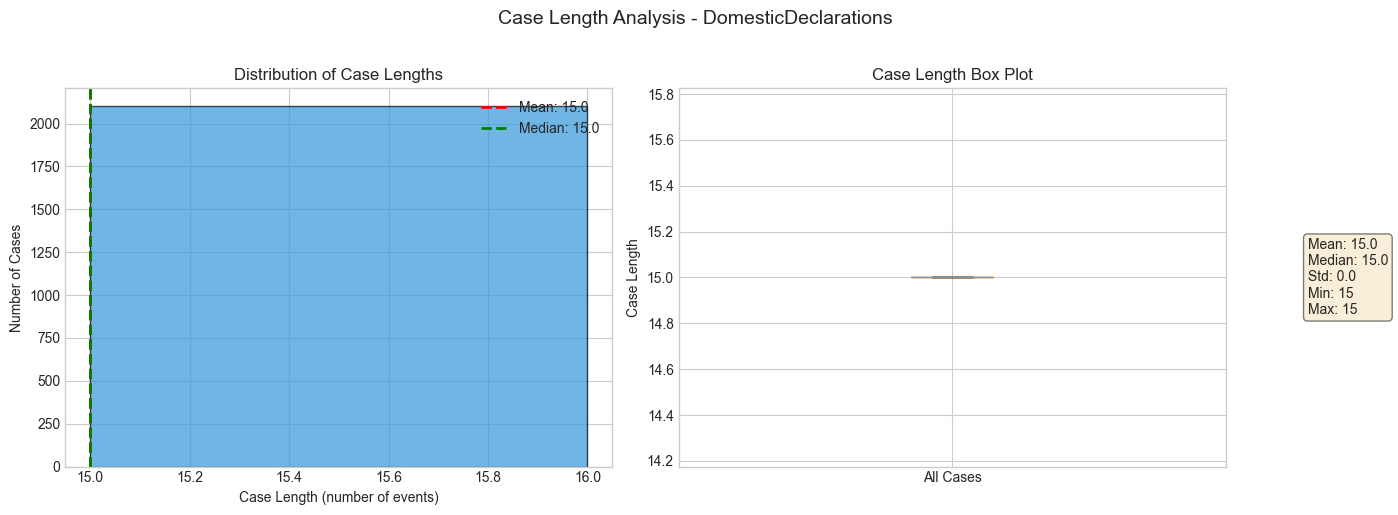

In [22]:
# Visualize case length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(case_lengths, bins=range(min_length, max_length + 2), edgecolor='black', alpha=0.7, color='#3498db')
ax.axvline(x=avg_length, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_length:.1f}')
ax.axvline(x=median_length, color='green', linestyle='--', linewidth=2, label=f'Median: {median_length:.1f}')
ax.set_xlabel('Case Length (number of events)')
ax.set_ylabel('Number of Cases')
ax.set_title('Distribution of Case Lengths')
ax.legend()

# Box plot
ax = axes[1]
bp = ax.boxplot(case_lengths, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][0].set_alpha(0.7)
ax.set_ylabel('Case Length')
ax.set_title('Case Length Box Plot')
ax.set_xticklabels(['All Cases'])

# Add statistics as text
stats_text = f'Mean: {avg_length:.1f}\nMedian: {median_length:.1f}\nStd: {std_length:.1f}\nMin: {min_length}\nMax: {max_length}'
ax.text(1.15, 0.5, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'Case Length Analysis - {CONFIG.dataset_name}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Activity Distribution

In [23]:
# Count activity frequencies
activity_counts = Counter(all_activities)
activity_df = pd.DataFrame([
    {'Activity': act, 'Count': count, 'Percentage': count / total_events * 100}
    for act, count in activity_counts.most_common()
])

print("\nActivity Frequency Distribution:")
print("="*70)
display(activity_df)


Activity Frequency Distribution:


,Activity,Count,Percentage
0,Unknown_0,20231,64.225397
1,APPROVED,2369,7.520635
2,SUBMITTED,2294,7.282540
3,FINAL_APPROVED,2019,6.409524
4,Payment Handled,1999,6.346032
5,Request Payment,1998,6.342857
6,REJECTED,561,1.780952
7,SAVED,29,0.092063


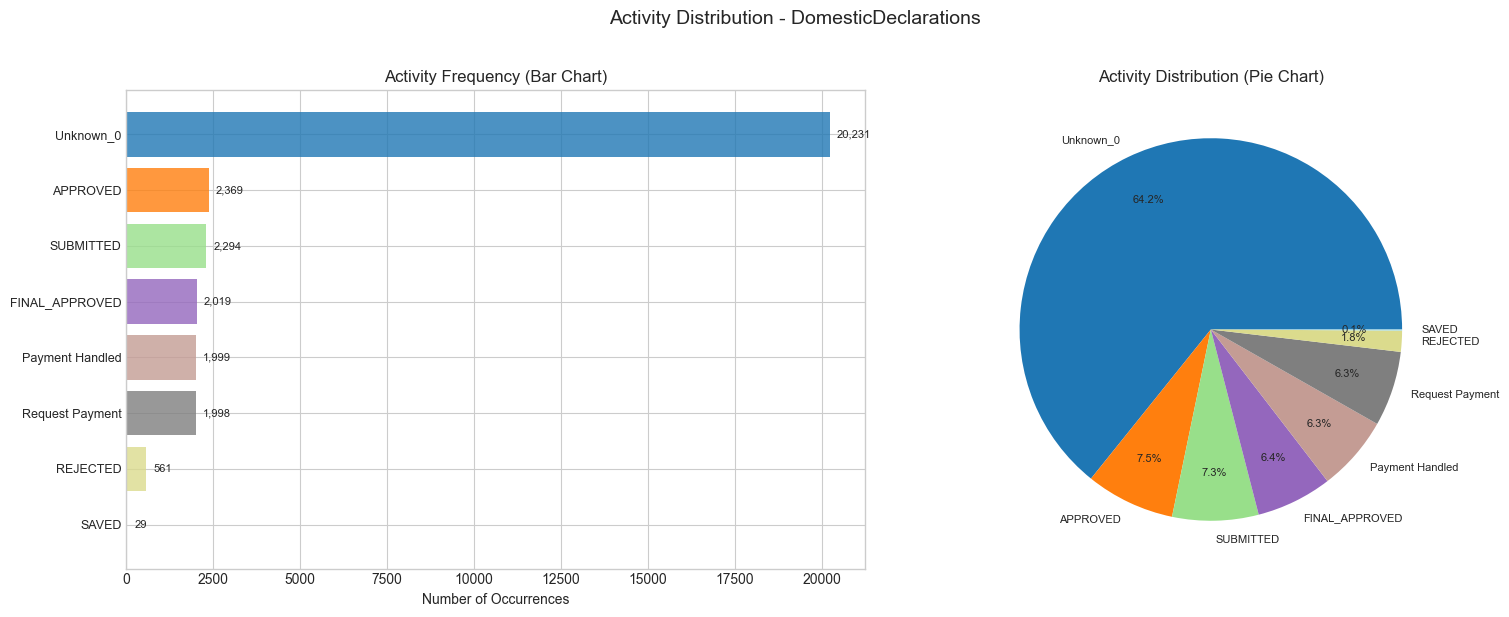

In [24]:
# Visualize activity distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
ax = axes[0]
activities = activity_df['Activity'].tolist()
counts = activity_df['Count'].tolist()

# Truncate long activity names for display
display_names = [act[:25] + '...' if len(act) > 25 else act for act in activities]

colors = plt.cm.tab20(np.linspace(0, 1, len(activities)))
bars = ax.barh(range(len(activities)), counts, color=colors, alpha=0.8)
ax.set_yticks(range(len(activities)))
ax.set_yticklabels(display_names, fontsize=9)
ax.set_xlabel('Number of Occurrences')
ax.set_title('Activity Frequency (Bar Chart)')
ax.invert_yaxis()

# Add count labels
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=8)

# Pie chart (top 10 + Other)
ax = axes[1]
top_n = 8
top_activities = activity_df.head(top_n)
other_count = activity_df.iloc[top_n:]['Count'].sum() if len(activity_df) > top_n else 0

pie_labels = top_activities['Activity'].apply(lambda x: x[:20] + '...' if len(x) > 20 else x).tolist()
pie_values = top_activities['Count'].tolist()

if other_count > 0:
    pie_labels.append(f'Other ({len(activity_df) - top_n} activities)')
    pie_values.append(other_count)

pie_colors = plt.cm.tab20(np.linspace(0, 1, len(pie_labels)))
wedges, texts, autotexts = ax.pie(pie_values, labels=pie_labels, autopct='%1.1f%%',
                                   colors=pie_colors, pctdistance=0.75)
ax.set_title('Activity Distribution (Pie Chart)')

# Make percentage text smaller
for autotext in autotexts:
    autotext.set_fontsize(8)
for text in texts:
    text.set_fontsize(8)

plt.suptitle(f'Activity Distribution - {CONFIG.dataset_name}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Process Variants (Activity Sequences)

In [25]:
# Build variant statistics
variant_to_cases = defaultdict(list)
for case_name, activities in case_activity_sequences.items():
    variant = tuple(activities)
    variant_to_cases[variant].append(case_name)

# Sort by frequency
sorted_variants = sorted(variant_to_cases.items(), key=lambda x: len(x[1]), reverse=True)

num_variants = len(sorted_variants)
top_variant_coverage = len(sorted_variants[0][1]) / num_cases * 100

print(f"\nProcess Variant Statistics:")
print("="*70)
print(f"{'Total unique variants:':<35} {num_variants:>10,}")
print(f"{'Top variant covers:':<35} {top_variant_coverage:>9.1f}% of cases")

# Calculate how many variants cover 80% of cases
cumulative = 0
variants_for_80 = 0
for variant, cases in sorted_variants:
    cumulative += len(cases)
    variants_for_80 += 1
    if cumulative / num_cases >= 0.8:
        break

print(f"{'Variants for 80% coverage:':<35} {variants_for_80:>10,}")


Process Variant Statistics:
Total unique variants:                      42
Top variant covers:                      48.9% of cases
Variants for 80% coverage:                   3


In [26]:
# Create variant summary table
variant_summary = []
for i, (variant, cases) in enumerate(sorted_variants[:20]):
    # Format sequence for display
    seq_display = ' -> '.join([act[:15] for act in variant[:4]])
    if len(variant) > 4:
        seq_display += f' -> ... ({len(variant)} total)'
    
    variant_summary.append({
        'Rank': i + 1,
        'Cases': len(cases),
        'Percentage': f"{len(cases)/num_cases*100:.1f}%",
        'Length': len(variant),
        'Activity Sequence': seq_display
    })

variant_df = pd.DataFrame(variant_summary)
print("\nTop 20 Most Common Process Variants:")
print("="*100)
display(variant_df)


Top 20 Most Common Process Variants:


,Rank,Cases,Percentage,Length,Activity Sequence
0,1,1026,48.9%,15,Unknown_0 -> Unknown_0 -> Unknown_0 -> Unknown...
1,2,509,24.2%,15,Unknown_0 -> Unknown_0 -> Unknown_0 -> Unknown...
2,3,273,13.0%,15,Unknown_0 -> Unknown_0 -> Unknown_0 -> Unknown...
3,4,71,3.4%,15,Unknown_0 -> Unknown_0 -> Unknown_0 -> Unknown...
4,5,44,2.1%,15,Unknown_0 -> Unknown_0 -> Unknown_0 -> Unknown...
5,6,41,2.0%,15,Unknown_0 -> Unknown_0 -> Unknown_0 -> Unknown...
6,7,29,1.4%,15,Unknown_0 -> Unknown_0 -> Unknown_0 -> Unknown...
7,8,22,1.0%,15,Unknown_0 -> Unknown_0 -> Unknown_0 -> Unknown...
8,9,16,0.8%,15,Unknown_0 -> Unknown_0 -> Unknown_0 -> Unknown...
9,10,8,0.4%,15,Unknown_0 -> Unknown_0 -> Unknown_0 -> Unknown...


In [27]:
# Show full sequences for top 5 variants
print("\nDetailed View - Top 5 Process Variants:")
print("="*100)

sum_of_top_5_cases = 0

for i, (variant, cases) in enumerate(sorted_variants[:5]):
    print(f"\n{'='*80}")
    sum_of_top_5_cases += len(cases)
    print(f"VARIANT {i+1}: {len(cases)} cases ({len(cases)/num_cases*100:.1f}%)")
    print(f"{'='*80}")
    print(f"Length: {len(variant)} activities")
    print(f"\nActivity Sequence:")
    for j, act in enumerate(variant):
        print(f"  {j+1:2d}. {act}")
    print(f"\nSample cases: {cases[:5]}")


Detailed View - Top 5 Process Variants:

VARIANT 1: 1026 cases (48.9%)
Length: 15 activities

Activity Sequence:
   1. Unknown_0
   2. Unknown_0
   3. Unknown_0
   4. Unknown_0
   5. Unknown_0
   6. Unknown_0
   7. Unknown_0
   8. Unknown_0
   9. Unknown_0
  10. Unknown_0
  11. SUBMITTED
  12. APPROVED
  13. FINAL_APPROVED
  14. Request Payment
  15. Payment Handled

Sample cases: ['declaration 100000', 'declaration 100149', 'declaration 100213', 'declaration 100223', 'declaration 100328']

VARIANT 2: 509 cases (24.2%)
Length: 15 activities

Activity Sequence:
   1. Unknown_0
   2. Unknown_0
   3. Unknown_0
   4. Unknown_0
   5. Unknown_0
   6. Unknown_0
   7. Unknown_0
   8. Unknown_0
   9. Unknown_0
  10. SUBMITTED
  11. APPROVED
  12. APPROVED
  13. FINAL_APPROVED
  14. Request Payment
  15. Payment Handled

Sample cases: ['declaration 100042', 'declaration 100105', 'declaration 100207', 'declaration 100289', 'declaration 100295']

VARIANT 3: 273 cases (13.0%)
Length: 15 activities

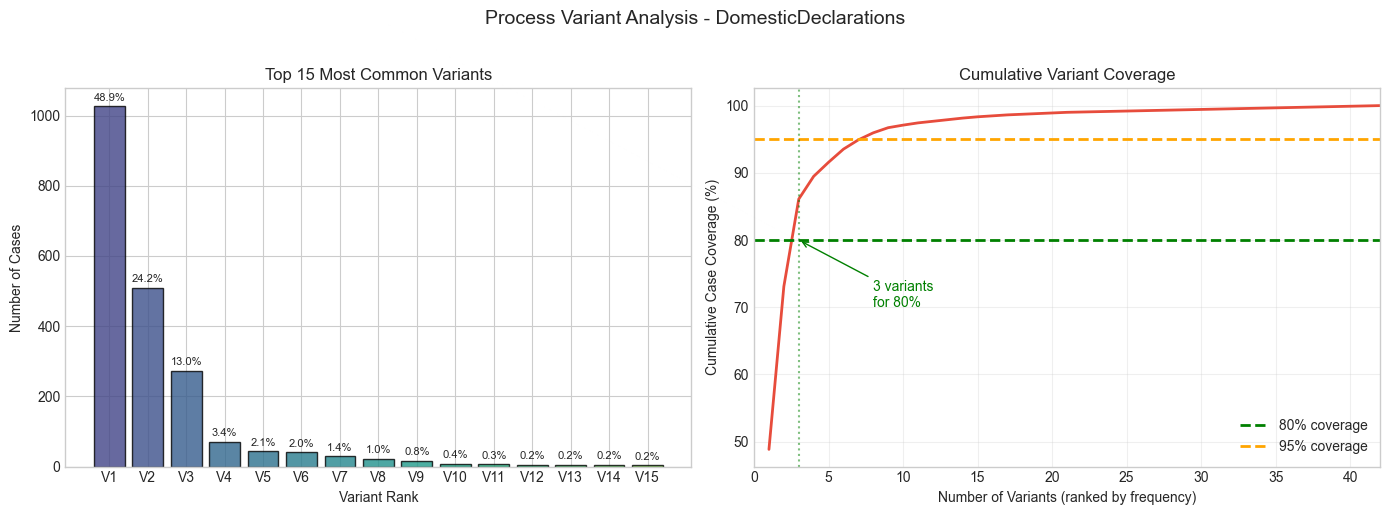

In [28]:
# Visualize variant distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of top variants
ax = axes[0]
top_n = min(15, len(sorted_variants))
variant_cases = [len(cases) for _, cases in sorted_variants[:top_n]]
variant_labels = [f'V{i+1}' for i in range(top_n)]

colors = plt.cm.viridis(np.linspace(0.2, 0.8, top_n))
bars = ax.bar(variant_labels, variant_cases, color=colors, alpha=0.8, edgecolor='black')
ax.set_xlabel('Variant Rank')
ax.set_ylabel('Number of Cases')
ax.set_title(f'Top {top_n} Most Common Variants')

# Add percentage labels
for bar, count in zip(bars, variant_cases):
    pct = count / num_cases * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(variant_cases)*0.01,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

# Cumulative coverage plot
ax = axes[1]
cumulative_coverage = np.cumsum([len(cases) for _, cases in sorted_variants]) / num_cases * 100
ax.plot(range(1, len(cumulative_coverage) + 1), cumulative_coverage, linewidth=2, color='#e74c3c')
ax.axhline(y=80, color='green', linestyle='--', linewidth=2, label='80% coverage')
ax.axhline(y=95, color='orange', linestyle='--', linewidth=2, label='95% coverage')
ax.axvline(x=variants_for_80, color='green', linestyle=':', alpha=0.5)
ax.set_xlabel('Number of Variants (ranked by frequency)')
ax.set_ylabel('Cumulative Case Coverage (%)')
ax.set_title('Cumulative Variant Coverage')
ax.legend()
ax.set_xlim(0, min(50, len(sorted_variants)))
ax.grid(True, alpha=0.3)

# Annotate 80% coverage point
ax.annotate(f'{variants_for_80} variants\nfor 80%', 
            xy=(variants_for_80, 80), xytext=(variants_for_80 + 5, 70),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=10, color='green')

plt.suptitle(f'Process Variant Analysis - {CONFIG.dataset_name}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

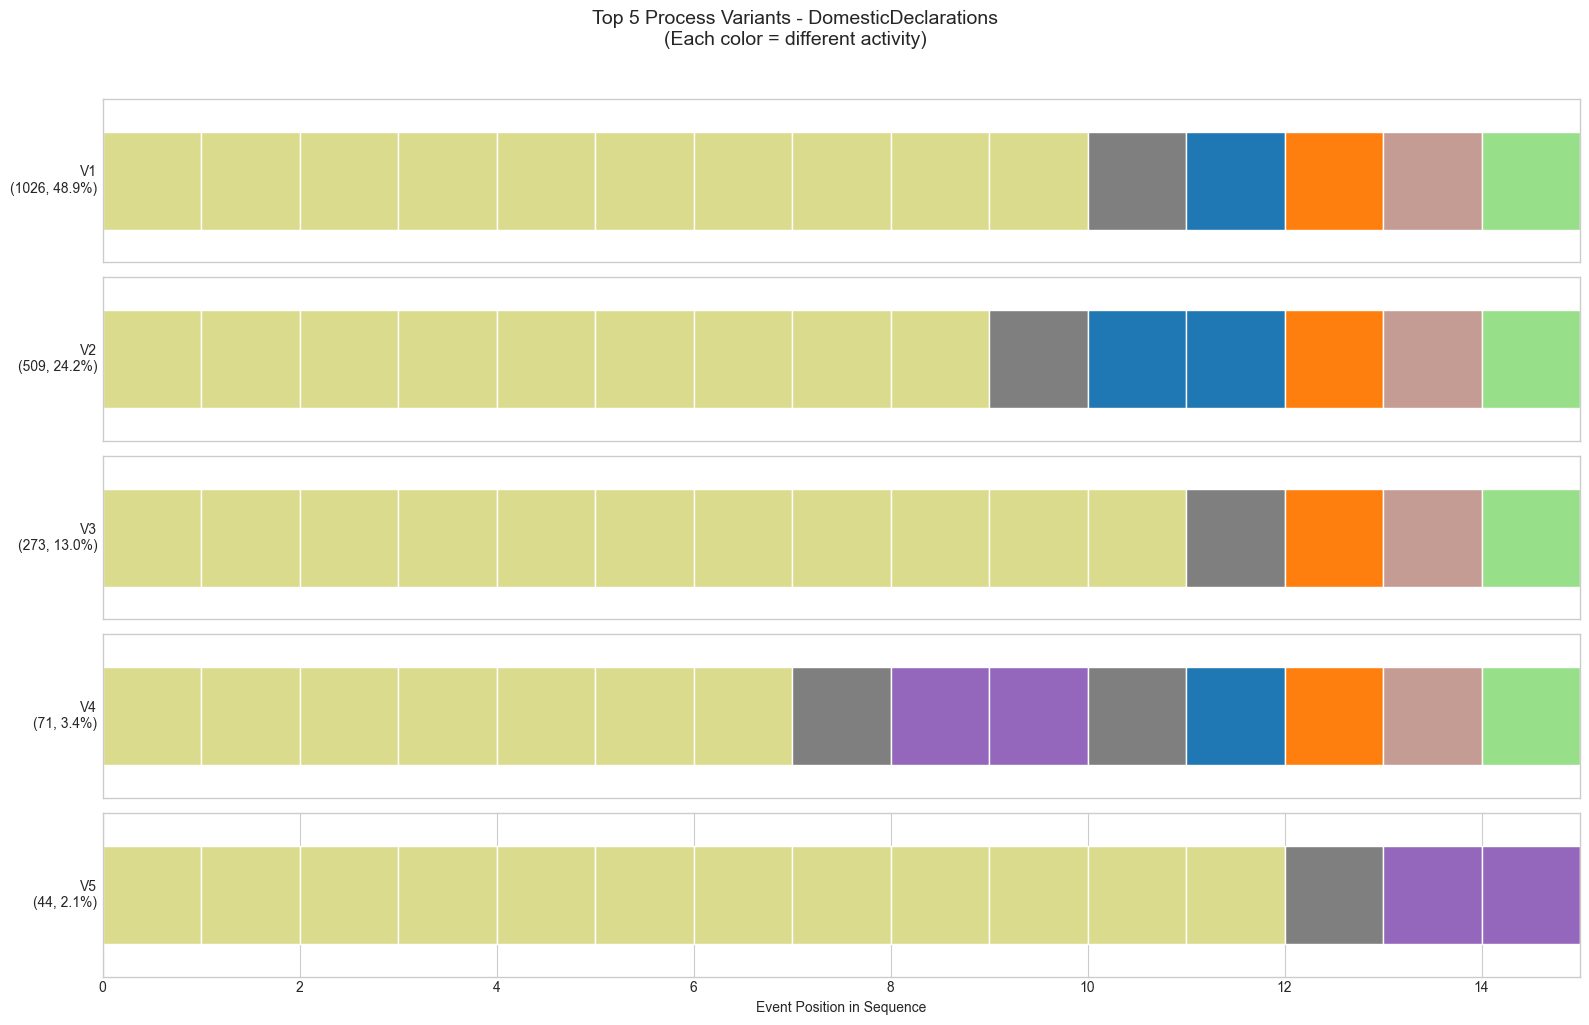

In [29]:
# Visualize top 5 variants as timeline
fig, axes = plt.subplots(5, 1, figsize=(16, 10))

# Get all unique activities across top 5 variants for consistent coloring
all_acts_top5 = set()
for variant, _ in sorted_variants[:5]:
    all_acts_top5.update(variant)
all_acts_top5 = sorted(all_acts_top5)
act_to_color = {act: plt.cm.tab20(i / len(all_acts_top5)) for i, act in enumerate(all_acts_top5)}

max_len = max(len(v) for v, _ in sorted_variants[:5])

for i, (variant, cases) in enumerate(sorted_variants[:5]):
    ax = axes[i]
    
    # Draw activity blocks
    for j, act in enumerate(variant):
        ax.barh(0, 1, left=j, height=0.6, color=act_to_color[act], 
               edgecolor='white', linewidth=1)
        # Add activity label if space allows
        if len(variant) <= 10:
            short_name = act[:10] + '..' if len(act) > 10 else act
            ax.text(j + 0.5, 0, short_name, ha='center', va='center', 
                   fontsize=7, rotation=45)
    
    ax.set_xlim(0, max_len)
    ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([])
    pct = len(cases) / num_cases * 100
    ax.set_ylabel(f'V{i+1}\n({len(cases)}, {pct:.1f}%)', rotation=0, ha='right', va='center', fontsize=10)
    
    if i == 4:
        ax.set_xlabel('Event Position in Sequence')
    else:
        ax.set_xticks([])

plt.suptitle(f'Top 5 Process Variants - {CONFIG.dataset_name}\n(Each color = different activity)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Activity Transitions

In [30]:
# Build transition matrix
transitions = defaultdict(lambda: defaultdict(int))

for activities in case_activity_sequences.values():
    for i in range(len(activities) - 1):
        from_act = activities[i]
        to_act = activities[i + 1]
        transitions[from_act][to_act] += 1

# Convert to DataFrame
unique_activities = sorted(set(all_activities))
transition_matrix = pd.DataFrame(0, index=unique_activities, columns=unique_activities)

for from_act in transitions:
    for to_act in transitions[from_act]:
        transition_matrix.loc[from_act, to_act] = transitions[from_act][to_act]

# Normalize by row (from activity)
transition_probs = transition_matrix.div(transition_matrix.sum(axis=1), axis=0).fillna(0)

print("\nTop Activity Transitions:")
print("="*70)

# Find top transitions
top_transitions = []
for from_act in transitions:
    for to_act, count in transitions[from_act].items():
        top_transitions.append((from_act, to_act, count))

top_transitions.sort(key=lambda x: x[2], reverse=True)

print(f"\n{'From Activity':<30} {'To Activity':<30} {'Count':>8}")
print("-"*70)
for from_act, to_act, count in top_transitions[:15]:
    from_short = from_act[:28] + '..' if len(from_act) > 28 else from_act
    to_short = to_act[:28] + '..' if len(to_act) > 28 else to_act
    print(f"{from_short:<30} {to_short:<30} {count:>8,}")


Top Activity Transitions:

From Activity                  To Activity                       Count
----------------------------------------------------------------------
Unknown_0                      Unknown_0                        18,132
Unknown_0                      SUBMITTED                         2,070
FINAL_APPROVED                 Request Payment                   1,998
Request Payment                Payment Handled                   1,997
SUBMITTED                      APPROVED                          1,783
APPROVED                       FINAL_APPROVED                    1,719
APPROVED                       APPROVED                            586
SUBMITTED                      FINAL_APPROVED                      300
REJECTED                       REJECTED                            265
REJECTED                       SUBMITTED                           224
SUBMITTED                      REJECTED                            211
APPROVED                       REJECTED          

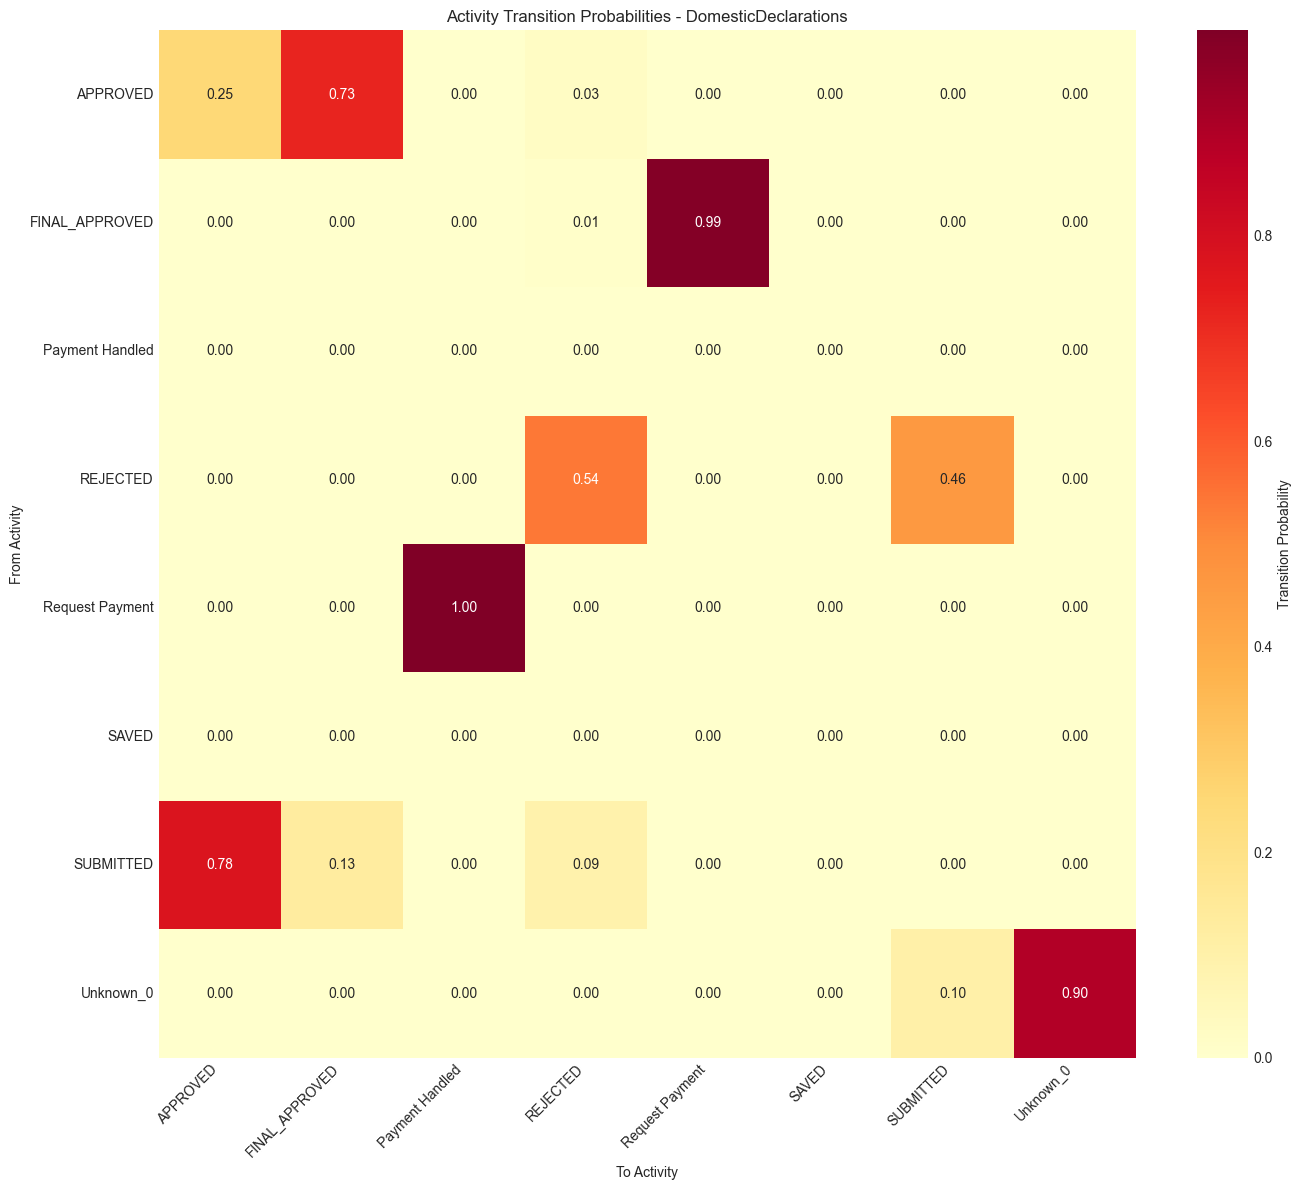

In [31]:
# Heatmap of transition probabilities
fig, ax = plt.subplots(figsize=(14, 12))

# Truncate activity names for display
short_names = [act[:20] + '..' if len(act) > 20 else act for act in unique_activities]

sns.heatmap(transition_probs.values, 
            xticklabels=short_names, 
            yticklabels=short_names,
            cmap='YlOrRd', 
            annot=True if len(unique_activities) <= 12 else False,
            fmt='.2f',
            ax=ax,
            cbar_kws={'label': 'Transition Probability'})

ax.set_xlabel('To Activity')
ax.set_ylabel('From Activity')
ax.set_title(f'Activity Transition Probabilities - {CONFIG.dataset_name}')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Summary

In [32]:
print("\n" + "="*80)
print(f"SUMMARY: {CONFIG.dataset_name} Dataset Overview")
print("="*80)

print(f"\n--- Basic Statistics ---")
print(f"  Total Cases:              {num_cases:,}")
print(f"  Total Events:             {total_events:,}")
print(f"  Unique Activities:        {len(set(all_activities))}")

print(f"\n--- Case Length ---")
print(f"  Average:                  {avg_length:.2f} events")
print(f"  Median:                   {median_length:.1f} events")
print(f"  Range:                    {min_length} - {max_length} events")
print(f"  Standard Deviation:       {std_length:.2f}")

print(f"\n--- Process Variants ---")
print(f"  Unique Variants:          {num_variants}")
print(f"  Most Common Variant:      {len(sorted_variants[0][1])} cases ({top_variant_coverage:.1f}%)")
print(f"  Variants for 80% Coverage: {variants_for_80}")

print(f"\n--- Top 3 Activities ---")
for i, (act, count) in enumerate(activity_counts.most_common(3)):
    pct = count / total_events * 100
    print(f"  {i+1}. {act[:40]}: {count:,} ({pct:.1f}%)")

print(f"\n--- Top 3 Process Variants ---")
for i, (variant, cases) in enumerate(sorted_variants[:3]):
    pct = len(cases) / num_cases * 100
    print(f"  {i+1}. {len(cases)} cases ({pct:.1f}%), {len(variant)} activities")
    print(f"     Sequence: {' -> '.join([a[:12] for a in variant[:4]])}...")


SUMMARY: DomesticDeclarations Dataset Overview

--- Basic Statistics ---
  Total Cases:              2,100
  Total Events:             31,500
  Unique Activities:        8

--- Case Length ---
  Average:                  15.00 events
  Median:                   15.0 events
  Range:                    15 - 15 events
  Standard Deviation:       0.00

--- Process Variants ---
  Unique Variants:          42
  Most Common Variant:      1026 cases (48.9%)
  Variants for 80% Coverage: 3

--- Top 3 Activities ---
  1. Unknown_0: 20,231 (64.2%)
  2. APPROVED: 2,369 (7.5%)
  3. SUBMITTED: 2,294 (7.3%)

--- Top 3 Process Variants ---
  1. 1026 cases (48.9%), 15 activities
     Sequence: Unknown_0 -> Unknown_0 -> Unknown_0 -> Unknown_0...
  2. 509 cases (24.2%), 15 activities
     Sequence: Unknown_0 -> Unknown_0 -> Unknown_0 -> Unknown_0...
  3. 273 cases (13.0%), 15 activities
     Sequence: Unknown_0 -> Unknown_0 -> Unknown_0 -> Unknown_0...
